In [1]:
import os
import glob
import numpy as np
import warnings
from Bio.PDB.PDBParser import PDBParser
from Bio import BiopythonWarning
from scipy.spatial.distance import cdist

warnings.simplefilter('ignore', BiopythonWarning)

CIF_DIR = "/share/home/wangtb/enzyme_shells/structure"

KEY_CATALYTIC_RESIDUES = {
    "PTEN": [(124, "CYS"), (130, "ARG")],
    "PTEN_2018": [(124, "CYS"), (130, "ARG")],
    "PAFA": [(79, "THR"), (38, "ASP"), (305, "ASP"), (352, "ASP"), (309, "HIS"), (353, "HIS"), (486, "HIS"), (100, "ASN"), (162, "LYS"), (164, "ARG")],
    
    "AICDA": [(58, "GLU"), (56, "HIS"), (87, "CYS"), (90, "CYS")],
    "AMIE": [(59, "GLU"), (134, "LYS"), (166, "CYS")],
    "CAS9": [(10, "ASP"), (840, "HIS"), (762, "GLU"), (766, "GLU"), (983, "HIS"), (1297, "HIS"), (1328, "ASP")],
    "LGK": [(23, "THR"), (26, "ASP"), (189, "GLY"), (192, "ASN"), (212, "ASP"), (217, "ASN"), (221, "ASP"), (234, "TYR"), (328, "GLY"), (362, "GLU")],
    "OTC": [(303, "CYS"), (90, "SER"), (141, "ARG"), (168, "HIS"), (171, "GLN"), (199, "ASN"), (263, "ASP"), (267, "SER"), (268, "MET"), (330, "ARG")],
    "RASH": [(13, "GLY"), (29, "VAL"), (59, "ALA"), (116, "ASN"), (145, "SER")],
    "RNC": [(45, "ASP"), (117, "GLU"), (41, "GLU"), (114, "ASP")],
    "VKOR1": [(80, "ASN"), (135, "CYS"), (139, "TYR")],
    "RUBISCO": [(166, "LYS"), (191, "LYS"), (193, "ASP"), (194, "GLU"), (287, "HIS"), (329, "LYS")]}

def auto_detect_offset(chain, expected_residues, max_shift=200):
    cif_seq_dict = {}
    for res in chain:
        if res.id[0] == ' ':
            cif_seq_dict[res.id[1]] = res.get_resname().upper()
            
    best_offset = 0
    max_matches = -1
    
    for offset in range(-max_shift, max_shift + 1):
        matches = 0
        for expected_id, expected_name in expected_residues:
            test_id = expected_id + offset
            if cif_seq_dict.get(test_id) == expected_name.upper():
                matches += 1
                
        if matches > max_matches:
            max_matches = matches
            best_offset = offset
            
        if max_matches == len(expected_residues):
            print(f"完全匹配！偏移量: {best_offset}，匹配数: {max_matches}/{len(expected_residues)}")
            break
            
    return best_offset, max_matches

def calculate_heavy_atom_distance(chain, active_site_res, cif_name):
    def get_heavy_atoms_coords(residue):
        coords = [atom.get_coord() for atom in residue if atom.element != 'H']
        return np.array(coords) if coords else np.array([])

    active_site_coords = []
    
    for res_id, expected_resname in active_site_res:
        try:
            target_res = chain[(' ', res_id, ' ')]
            actual_resname = target_res.resname.upper()
            
            if actual_resname != expected_resname.upper():
                print(f"  提示：序列变异！在 {cif_name} 位置 {res_id} 字典期望是 {expected_resname}，但结构中是 {actual_resname}。已采用当前残基计算。")
            
            res_coords = get_heavy_atoms_coords(target_res)
            active_site_coords.extend(res_coords)
            
        except KeyError:
            print(f"错误：在 {cif_name} 中未找到指定的残基位置 {res_id}。")
            return {} 
            
    active_site_coords = np.array(active_site_coords)
    if active_site_coords.size == 0:
        print(f"错误：{cif_name} 未能提取到任何催化中心重原子。")
        return {}
    
    distance_dict = {}
    for res in chain:
        if res.id[0] == ' ':  
            res_id = res.id[1]
            res_coords = get_heavy_atoms_coords(res)
            
            if res_coords.size > 0 and active_site_coords.size > 0:
                dist_matrix = cdist(res_coords, active_site_coords)
                min_dist = np.min(dist_matrix)
                distance_dict[res_id] = round(min_dist, 3)
                
    return distance_dict

def get_all_catalytic_distances():
    # 1. 搜索后缀改为 .pdb
    pdb_files = glob.glob(os.path.join(CIF_DIR, "*.pdb"))
    all_distances = {}
    
    # 2. 换用 PDBParser 解析器
    parser = PDBParser(QUIET=True)
    
    if not pdb_files:
        print(f"在 {CIF_DIR} 中未找到 PDB 文件。")
        return all_distances

    for pdb_path in pdb_files:
        filename = os.path.basename(pdb_path)
        # 3. 截取 ID 时，把去掉 .cif 改为去掉 .pdb
        pdb_id = filename.replace('.pdb', '').upper()
        
        if pdb_id not in KEY_CATALYTIC_RESIDUES:
            continue
            
        original_res_list = KEY_CATALYTIC_RESIDUES[pdb_id]
        
        try:
            # 读取 pdb 文件
            structure = parser.get_structure('Target', pdb_path)
            chain = structure[0]['A']
        except Exception as e:
            print(f"解析 {pdb_path} 失败: {e}")
            continue

        offset, matches = auto_detect_offset(chain, original_res_list)
        total_expected = len(original_res_list)
        
        if offset != 0:
            print(f"[{pdb_id}] 检测到编号错位，已自动应用偏移量: {offset} (成功匹配残基: {matches}/{total_expected})")
        elif matches < total_expected:
            print(f"[{pdb_id}] 警告：未检测到错位偏移，但部分残基无法完美匹配 ({matches}/{total_expected})")

        mapped_res_list = [(res_id + offset, res_name) for res_id, res_name in original_res_list]
        
        dist_dict = calculate_heavy_atom_distance(chain, mapped_res_list, filename)
        
        if dist_dict:
            all_distances[pdb_id] = dist_dict
            
    print("\n批量计算完成！已返回嵌套字典。")
    return all_distances

distances_dict = get_all_catalytic_distances()
print("包含以下 PDB ID 的距离数据：")
for pdb_id in distances_dict.keys():
    print(f"  - {pdb_id}")
    

完全匹配！偏移量: 0，匹配数: 6/6
完全匹配！偏移量: 0，匹配数: 4/4
完全匹配！偏移量: 0，匹配数: 3/3
完全匹配！偏移量: 0，匹配数: 7/7
完全匹配！偏移量: 0，匹配数: 10/10
完全匹配！偏移量: 0，匹配数: 10/10
完全匹配！偏移量: 0，匹配数: 2/2
完全匹配！偏移量: 0，匹配数: 5/5
完全匹配！偏移量: 0，匹配数: 4/4
完全匹配！偏移量: 0，匹配数: 3/3
完全匹配！偏移量: 0，匹配数: 10/10
完全匹配！偏移量: 0，匹配数: 2/2

批量计算完成！已返回嵌套字典。
包含以下 PDB ID 的距离数据：
  - RUBISCO
  - AICDA
  - AMIE
  - CAS9
  - LGK
  - OTC
  - PTEN_2018
  - RASH
  - RNC
  - VKOR1
  - PAFA
  - PTEN


接下来，解析一下MPNN计算结果，看看长什么样

In [2]:
import torch

file_path = "/share/home/wangtb/enzyme_shells/mpnn/RUBISCO/RUBISCO.pt"
data = torch.load(file_path, map_location='cpu')

print(f"Data type: {type(data)}")

if isinstance(data, dict):
    for key, value in data.items():
        if isinstance(value, torch.Tensor):
            print(f"Key: '{key}', Type: Tensor, Shape: {value.shape}")
        elif isinstance(value, list) or isinstance(value, dict) or isinstance(value, str):
            print(f"Key: '{key}', Type: {type(value).__name__}, Size/Length: {len(value)}")
        else:
            print(f"Key: '{key}', Type: {type(value).__name__}, Value: {value}")
            
elif isinstance(data, list) and len(data) > 0:
    print(f"List contains {len(data)} items. First item type: {type(data[0])}")
    if isinstance(data[0], dict):
        for k, v in data[0].items():
            if isinstance(v, torch.Tensor):
                print(f"Key: '{k}', Type: Tensor, Shape: {v.shape}")
            else:
                print(f"Key: '{k}', Type: {type(v).__name__}")

Data type: <class 'dict'>
Key: 'logits', Type: ndarray, Value: [[[ 0.5414214  -1.63377    -0.31505343 ... -1.107309   -0.64885974
   -2.42267   ]
  [ 0.36934274 -1.7749164  -0.09662777 ... -1.6187335  -0.88217264
   -2.437615  ]
  [ 0.46577966 -1.19439    -0.27419862 ... -1.8908311  -0.95211464
   -2.6146307 ]
  ...
  [ 0.2071306  -0.49820536 -0.02064674 ... -0.46021286 -0.14115681
   -1.2206851 ]
  [ 0.67282087 -1.7175543   0.19519694 ... -1.0162568  -0.7758133
   -2.2337446 ]
  [ 0.7395145  -1.5260482   0.51174337 ... -1.8827453  -1.5426999
   -2.4218593 ]]]
Key: 'probs', Type: ndarray, Value: [[[0.08869091 0.01007408 0.03766316 ... 0.01705472 0.02697408 0.0045771 ]
  [0.07868047 0.00921779 0.04937403 ... 0.01077597 0.0225082  0.00475139]
  [0.09261597 0.01760692 0.04418933 ... 0.00877451 0.02243377 0.00425481]
  ...
  [0.06420032 0.03171127 0.05112282 ... 0.03293924 0.04531875 0.0153973 ]
  [0.08790928 0.00805208 0.05452621 ... 0.01623594 0.02064909 0.0048054 ]
  [0.1140876  0.01183

In [3]:
import os
import glob
import numpy as np
import torch
import re
import warnings
from Bio.PDB.PDBParser import PDBParser
from Bio.PDB.MMCIFParser import MMCIFParser
from Bio.PDB.Polypeptide import protein_letters_3to1
from Bio.Align import PairwiseAligner
from Bio import BiopythonWarning

warnings.simplefilter('ignore', BiopythonWarning)

# ================= 路径配置 =================
AF_DIR = "/share/home/wangtb/enzyme_shells/structure"
DCA_BASE = "/share/home/wangtb/enzyme_shells/dca"
MPNN_BASE = "/share/home/wangtb/enzyme_shells/mpnn"

# 根据 ls 结果更新了目标蛋白列表 (排除了 run_mpnn.sh)
PROTEIN_IDS = [
    "AICDA", "AMIE", "CAS9", "LGK", "OTC", "PAFA", 
    "PTEN", "PTEN_2018", "RASH", "RNC", "RUBISCO", "VKOR1"
]
# ============================================

def calc_metrics_from_muts(mut_dict, target_aa):
    if not mut_dict:
        return np.nan, np.nan

    all_scores = np.array(list(mut_dict.values()))
    probs = np.exp(-all_scores)
    Z = np.sum(probs) + 1e-10
    
    norm_probs = probs / Z
    entropy = -np.sum(norm_probs * np.log(norm_probs + 1e-10)) 
    
    target_score = mut_dict.get(target_aa, 0.0)
    logp = np.log(np.exp(-target_score) / Z)
    
    return float(logp), float(entropy)

def get_pdb_sequence(struct_path, chain_id):
    # 自动识别 .pdb 或 .cif 并使用对应的 Parser
    if struct_path.endswith('.cif'):
        parser = MMCIFParser(QUIET=True)
    else:
        parser = PDBParser(QUIET=True)
        
    try:
        struct = parser.get_structure("target", struct_path)
        chain = struct[0][chain_id]
    except Exception as e:
        print(f"解析结构文件出错: {e}")
        return [], "", {}

    pdb_dict = {}
    seq = []
    res_ids = []

    for res in chain:
        if res.id[0] == ' ':
            resname = res.get_resname()
            if resname in protein_letters_3to1:
                rid = int(res.id[1])
                aa = protein_letters_3to1[resname]
                pdb_dict[rid] = aa
                seq.append(aa)
                res_ids.append(rid)

    return res_ids, "".join(seq), pdb_dict

def align_sequence(source_seq, target_pdb_seq, target_pdb_ids, source_indices, source_name=""):
    aligner = PairwiseAligner()
    aligner.mode = "local"
    aligner.match_score = 2
    aligner.mismatch_score = -1
    aligner.open_gap_score = -5
    aligner.extend_gap_score = -1
    
    alns = aligner.align(source_seq, target_pdb_seq)
    if not alns:
        return {}
        
    aln = alns[0]
    mapping = {}
    
    for (src_start, src_end), (tgt_start, tgt_end) in zip(aln.aligned[0], aln.aligned[1]):
        for i in range(tgt_end - tgt_start):
            mapping[target_pdb_ids[tgt_start + i]] = source_indices[src_start + i]

    return mapping

def parse_dca(fasta_path):
    dca_data = {}
    with open(fasta_path, "r") as f:
        for line in f:
            if line.startswith(">"):
                words = line.strip()[1:].split("|")
                match = re.search(r'([a-zA-Z])\s*(\d+)\s*([a-zA-Z\-])', words[0])
                if match:
                    wt_aa = match.group(1).upper()
                    idx = int(match.group(2))
                    mut_aa = match.group(3).upper()
                    try:
                        score = float(words[1].split()[-1])
                    except ValueError:
                        continue
                    
                    if idx not in dca_data:
                        dca_data[idx] = {'wt': wt_aa, 'muts': {wt_aa: 0.0}}
                    if mut_aa != "-" and mut_aa != wt_aa:
                        dca_data[idx]['muts'][mut_aa] = score

    if not dca_data:
        return "", {}, []

    sorted_indices = sorted(list(dca_data.keys()))
    dca_seq = "".join([dca_data[i]['wt'] for i in sorted_indices])
            
    return dca_seq, dca_data, sorted_indices

def parse_mpnn(pt_path, target_chain_id):
    # 使用修复后的健壮版解析逻辑
    data = torch.load(pt_path, map_location='cpu')
    mpnn_data = {}
    
    local_idx = 0
    global_idx = 0
    
    valid_chains = set()
    for pos_key in data["mean_of_probs"]:
        match = re.match(r'^([a-zA-Z]+)(\d+.*)$', pos_key)
        if match: valid_chains.add(match.group(1))
        
    sorted_chains = sorted(list(valid_chains), key=len, reverse=True)
    sequence_list = data.get("sequence", [])

    for pos_key, probs_dict in data["mean_of_probs"].items():
        matched_chain = "Unknown"
        for v_chain in sorted_chains:
            if pos_key.startswith(v_chain):
                matched_chain = v_chain
                break
                
        if matched_chain == target_chain_id:
            wt = sequence_list[global_idx] if global_idx < len(sequence_list) else "X"
            
            mpnn_data[local_idx] = {'wt': wt, 'muts': {wt: 0.0}}
            wt_p = probs_dict.get(wt, 0.0)

            for mut, mut_p in probs_dict.items():
                if wt_p > 0 and mut_p > 0 and mut != wt:
                    score = float(np.log(wt_p) - np.log(mut_p))
                    mpnn_data[local_idx]['muts'][mut] = score

            local_idx += 1
        global_idx += 1

    sorted_indices = sorted(list(mpnn_data.keys()))
    seq_chars = "".join([mpnn_data[i]['wt'] for i in sorted_indices])
    return seq_chars, mpnn_data, sorted_indices


all_proteins_data = {}

print("开始批量提取模型得分、序列对齐校验并合并数据...\n")

for pid in PROTEIN_IDS:
    print(f"正在处理: {pid} ...")
    
    af_distance = distances_dict.get(pid, {}) if 'distances_dict' in globals() else {}
    
    # 自动检索 .pdb 或 .cif 后缀
    cif_path = os.path.join(AF_DIR, f"{pid}.cif")
    pdb_path = os.path.join(AF_DIR, f"{pid}.pdb")
    if os.path.exists(cif_path):
        struct_path = cif_path
    elif os.path.exists(pdb_path):
        struct_path = pdb_path
    else:
        print(f"  跳过: 未找到 {pid} 的结构文件 (.pdb 缺或 .cif 缺)")
        continue

    res_ids, pdb_seq, pdb_dict = get_pdb_sequence(struct_path, "A")
    
    if not res_ids:
        print(f"  跳过: 未能从 {pid} 的 A 链提取到结构序列。")
        continue

    # DCA 路径更新 (直接以 {pid}.fasta 结尾)
    dca_path = os.path.join(DCA_BASE, f"{pid}.fasta")
    dca_seq, dca_data, dca_indices = ("", {}, [])
    if os.path.exists(dca_path):
        dca_seq, dca_data, dca_indices = parse_dca(dca_path)
    else:
        print(f"  警告: 未找到 {pid} 的 DCA 结果 ({dca_path})")

    # MPNN 路径更新 (访问子文件夹: {pid}/{pid}.pt)
    mpnn_path = os.path.join(MPNN_BASE, pid, f"{pid}.pt")
    mpnn_seq, mpnn_data, mpnn_indices = ("", {}, [])
    if os.path.exists(mpnn_path):
        mpnn_seq, mpnn_data, mpnn_indices = parse_mpnn(mpnn_path, "A")
    else:
        print(f"  警告: 未找到 {pid} 的 MPNN 结果 ({mpnn_path})")

    dca_map = align_sequence(dca_seq, pdb_seq, res_ids, dca_indices, source_name="DCA") if dca_seq else {}
    mpnn_map = align_sequence(mpnn_seq, pdb_seq, res_ids, mpnn_indices, source_name="MPNN") if mpnn_seq else {}

    dca_logp_dict, dca_entropy_dict, dca_score_dict = {}, {}, {}
    mpnn_logp_dict, mpnn_entropy_dict, mpnn_score_dict = {}, {}, {}
    
    dca_all_muts_dict = {}
    mpnn_all_muts_dict = {}
    
    validation_mapping = {}

    mapped_count = 0
    dca_mismatch = 0
    mpnn_mismatch = 0

    for rid, pdb_aa in pdb_dict.items():
        val_entry = {"pdb_aa": pdb_aa, "dca_wt": None, "mpnn_wt": None}
        is_mapped = False

        if rid in dca_map:
            d_idx = dca_map[rid]
            if d_idx in dca_data:
                is_mapped = True
                dca_wt = dca_data[d_idx]['wt']
                val_entry["dca_wt"] = dca_wt
                
                if pdb_aa != dca_wt:
                    dca_mismatch += 1
                
                muts_dict = dca_data[d_idx]['muts']
                logp, ent = calc_metrics_from_muts(muts_dict, target_aa=pdb_aa)
                
                dca_logp_dict[rid] = logp
                dca_entropy_dict[rid] = ent
                dca_score_dict[rid] = muts_dict.get(pdb_aa, 0.0) 
                dca_all_muts_dict[rid] = muts_dict 
                
        if rid in mpnn_map:
            m_idx = mpnn_map[rid]
            if m_idx in mpnn_data:
                is_mapped = True
                mpnn_wt = mpnn_data[m_idx]['wt']
                val_entry["mpnn_wt"] = mpnn_wt
                
                if pdb_aa != mpnn_wt:
                    mpnn_mismatch += 1

                muts_dict = mpnn_data[m_idx]['muts']
                logp, ent = calc_metrics_from_muts(muts_dict, target_aa=pdb_aa)
                
                mpnn_logp_dict[rid] = logp
                mpnn_entropy_dict[rid] = ent
                mpnn_score_dict[rid] = muts_dict.get(pdb_aa, 0.0) 
                mpnn_all_muts_dict[rid] = muts_dict 
        
        if is_mapped:
            mapped_count += 1
            validation_mapping[rid] = val_entry

    print(f"    - 成功映射残基: {mapped_count} / {len(pdb_dict)}")
    if dca_mismatch > 0:
        print(f"    - DCA序列冲突: 发现 {dca_mismatch} 处 PDB序列 与 DCA输入野生型 不一致！(已自适应取对应氨基酸分数)")
    if mpnn_mismatch > 0:
        print(f"    - MPNN序列冲突: 发现 {mpnn_mismatch} 处 PDB序列 与 MPNN输入野生型 不一致！(已自适应取对应氨基酸分数)")

    all_proteins_data[pid] = {
        "af_distance": af_distance,      
        "dca_logp": dca_logp_dict,            
        "dca_entropy": dca_entropy_dict,
        "dca_score": dca_score_dict,          
        "dca_all_muts": dca_all_muts_dict,
        "mpnn_logp": mpnn_logp_dict,          
        "mpnn_entropy": mpnn_entropy_dict,
        "mpnn_score": mpnn_score_dict,        
        "mpnn_all_muts": mpnn_all_muts_dict,
        "validation_mapping": validation_mapping
    }

print("\n处理完成！最终数据及校验报告已整合到 all_proteins_data 字典中。")

开始批量提取模型得分、序列对齐校验并合并数据...

正在处理: AICDA ...
    - 成功映射残基: 198 / 198
正在处理: AMIE ...


    - 成功映射残基: 346 / 346
正在处理: CAS9 ...
    - 成功映射残基: 1390 / 1390
正在处理: LGK ...
    - 成功映射残基: 439 / 439
正在处理: OTC ...
    - 成功映射残基: 354 / 354
正在处理: PAFA ...
    - 成功映射残基: 546 / 546
正在处理: PTEN ...
    - 成功映射残基: 403 / 403
正在处理: PTEN_2018 ...
    - 成功映射残基: 403 / 403
正在处理: RASH ...
    - 成功映射残基: 189 / 189
正在处理: RNC ...
    - 成功映射残基: 226 / 226
正在处理: RUBISCO ...
    - 成功映射残基: 459 / 459
正在处理: VKOR1 ...
    - 成功映射残基: 163 / 163

处理完成！最终数据及校验报告已整合到 all_proteins_data 字典中。


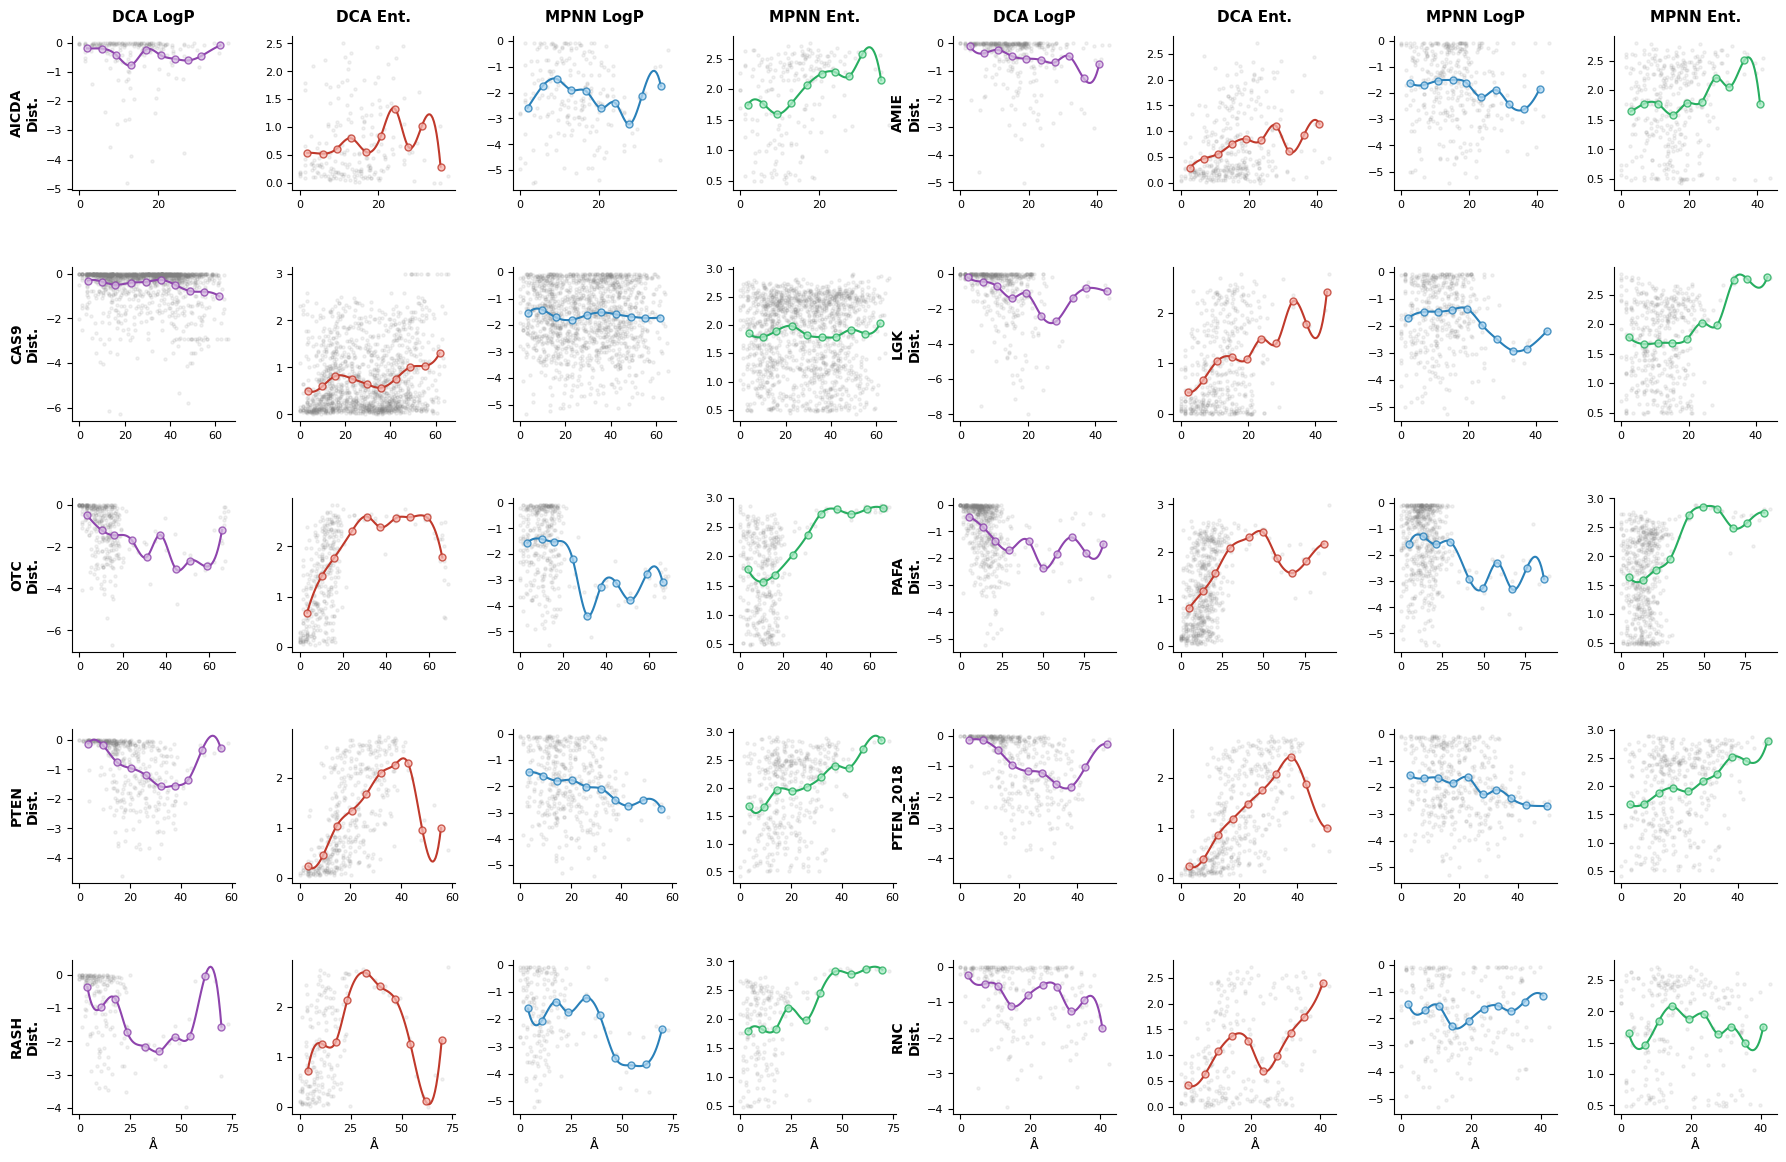

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline

def plot_proteins_5x2_grid(all_proteins_data, default_bins=10):
    # 定义指标和标题
    metrics = ["dca_logp", "dca_entropy", "mpnn_logp", "mpnn_entropy"]
    short_titles = ["DCA LogP", "DCA Ent.", "MPNN LogP", "MPNN Ent."]
    
    # 颜色配置
    colors = [
        ('#8E44AD', '#D7BDE2'), # DCA LogP - 紫
        ('#C0392B', '#F5B7B1'), # DCA Entropy - 红
        ('#2980B9', '#AED6F1'), # MPNN LogP - 蓝
        ('#27AE60', '#ABEBC6')  # MPNN Entropy - 绿
    ]
    
    protein_ids = list(all_proteins_data.keys())
    # 确保只处理前10个，或者根据实际数量调整
    n_proteins = len(protein_ids)
    
    # 创建 5行 x 8列 的画布
    # 每列宽度约 3 英寸，总宽 22 英寸，总高 15 英寸
    fig, axes = plt.subplots(5, 8, figsize=(22, 14))
    
    for i, pid in enumerate(protein_ids):
        if i >= 10: break # 只处理前10个
        
        # 计算当前蛋白在 5x2 蛋白网格中的位置
        row = i // 2
        col_offset = (i % 2) * 4 # 左边蛋白占 0-3 列，右边蛋白占 4-7 列
        
        feats = all_proteins_data[pid]
        distances = feats.get("af_distance", {})
        
        # 准备数据
        data_list = []
        for pos, dist in distances.items():
            entry = {"dist": dist}
            for m in metrics:
                entry[m] = feats.get(m, {}).get(pos, np.nan)
            data_list.append(entry)
        df = pd.DataFrame(data_list)

        # 依次绘制该蛋白的 4 个指标
        for m_idx, m_col in enumerate(metrics):
            ax = axes[row, col_offset + m_idx]
            line_c, scatter_c = colors[m_idx]
            
            curr_df = df.dropna(subset=["dist", m_col]).copy()
            
            if curr_df.empty:
                ax.text(0.5, 0.5, "N/A", transform=ax.transAxes, ha='center', color='gray')
            else:
                # 分箱处理
                n_bins = min(default_bins, max(4, len(curr_df) // 15))
                curr_df['bin'] = pd.cut(curr_df["dist"], bins=n_bins, labels=False)
                grouped = curr_df.groupby('bin', observed=True).mean(numeric_only=True).reset_index()
                
                x_raw, y_raw = curr_df["dist"].values, curr_df[m_col].values
                x_bin, y_bin = grouped["dist"].values, grouped[m_col].values

                # 绘制背景散点
                ax.scatter(x_raw, y_raw, alpha=0.1, s=5, color='gray', zorder=1)
                
                # 绘制分箱点
                ax.scatter(x_bin, y_bin, s=25, color=scatter_c, edgecolor=line_c, alpha=0.8, zorder=3)
                
                # 绘制平滑趋势线
                if len(x_bin) > 3:
                    try:
                        x_smooth = np.linspace(x_bin.min(), x_bin.max(), 100)
                        spline = make_interp_spline(np.sort(x_bin), y_bin[np.argsort(x_bin)], k=3)
                        ax.plot(x_smooth, spline(x_smooth), color=line_c, linewidth=1.5, zorder=2)
                    except:
                        ax.plot(np.sort(x_bin), y_bin[np.argsort(x_bin)], color=line_c, linewidth=1.5, zorder=2)


            if row == 0:
                ax.set_title(short_titles[m_idx], fontsize=11, fontweight='bold', pad=10)
            
            if m_idx == 0:
                ax.set_ylabel(f"{pid}\nDist.", fontsize=10, fontweight='bold')
            else:
                ax.set_ylabel("")

            if row == 4:
                ax.set_xlabel("Å", fontsize=9)
            
            ax.tick_params(axis='both', which='major', labelsize=8)
            sns.despine(ax=ax)

    plt.subplots_adjust(wspace=0.35, hspace=0.5)

    plt.show()

# 调用绘图
plot_proteins_5x2_grid(all_proteins_data)

In [5]:
import os
import glob
import pandas as pd
import re
import numpy as np

# 路径配置
CSV_DIR = "/share/home/wangtb/enzyme_shells/activity_data"

csv_files = glob.glob(os.path.join(CSV_DIR, "*.csv"))

print("开始批量校验突变位点并更新得分及距离 (直接覆盖原文件)...\n")

for csv_file in csv_files:
    filename = os.path.basename(csv_file)

    valid_pids = sorted(list(all_proteins_data.keys()), key=len, reverse=True)
    
    pid = None
    for vp in valid_pids:
        if vp.upper() in filename.upper():
            pid = vp
            break

    if not pid:
        print(f"跳过无法从文件名识别对应蛋白 ID 的文件: {filename}")
        continue
    
    try:
        df = pd.read_csv(csv_file)
    except Exception as e:
        print(f"读取 {filename} 失败: {e}")
        continue

    # 自动识别突变列名
    mut_col = None
    if 'mutant' in df.columns:
        mut_col = 'mutant'
    elif 'Variant (one letter)' in df.columns:
        mut_col = 'Variant (one letter)'

    if not mut_col:
        print(f"{filename} 中未找到 mutant 或 Variant 列，跳过")
        continue

    prot_data = all_proteins_data[pid]

    updated_dca = []
    updated_mpnn = []
    updated_distance = []

    match_count = 0
    mismatch_count = 0

    for idx, row in df.iterrows():
        mut_str = str(row[mut_col])

        if pd.isna(mut_str) or mut_str.strip() == '':
            updated_dca.append(np.nan)
            updated_mpnn.append(np.nan)
            updated_distance.append(np.nan)
            continue

        # 按 '/' 拆分多点突变 (如 H45R/W47Y/I50F)
        mutations = mut_str.split('/')
        row_dca_scores = []
        row_mpnn_scores = []
        row_distances = []

        for m in mutations:
            m = m.strip()

            # 解析例如 "I155T" -> wt='I', pos=155, mut='T'
            parsed = re.match(r'([a-zA-Z])(\d+)([a-zA-Z])', m)

            if parsed:
                csv_wt = parsed.group(1).upper()
                pos = int(parsed.group(2))
                mut_aa = parsed.group(3).upper()

                # 获取结构距离
                dist = prot_data.get('af_distance', {}).get(pos, np.nan)

                # 核心检验：CSV里的野生型 vs 真实结构字典里的野生型
                val_info = prot_data['validation_mapping'].get(pos)

                if val_info and val_info['pdb_aa'] == csv_wt:
                    # 匹配成功！查阅突变体的具体得分
                    d_score = prot_data['dca_all_muts'].get(pos, {}).get(mut_aa, np.nan)
                    m_score = prot_data['mpnn_all_muts'].get(pos, {}).get(mut_aa, np.nan)
                    match_count += 1
                else:
                    # 不匹配或结构中缺失该残基
                    d_score, m_score = np.nan, np.nan
                    mismatch_count += 1

                row_dca_scores.append(str(round(d_score, 4)) if pd.notna(d_score) else "NaN")
                row_mpnn_scores.append(str(round(m_score, 4)) if pd.notna(m_score) else "NaN")
                row_distances.append(str(round(dist, 3)) if pd.notna(dist) else "NaN")
            else:
                row_dca_scores.append("NaN")
                row_mpnn_scores.append("NaN")
                row_distances.append("NaN")

        # 重新用 '/' 拼接多点突变的得分和距离
        updated_dca.append("/".join(row_dca_scores))
        updated_mpnn.append("/".join(row_mpnn_scores))
        updated_distance.append("/".join(row_distances))

    # 直接覆盖原始列
    df['DCA_score'] = updated_dca
    df['LigandMPNN_score'] = updated_mpnn
    df['Distance_to_Active_Site'] = updated_distance

    # 直接在原文件写入
    df.to_csv(csv_file, index=False)

    print(f"{pid} ({filename}) 处理完毕并已覆盖原文件 | 成功匹配: {match_count} 处 | 冲突/缺失: {mismatch_count} 处")
    print("-" * 40)

print("所有 CSV 文件已在原目录更新完毕！")

开始批量校验突变位点并更新得分及距离 (直接覆盖原文件)...

PTEN (PTEN.csv) 处理完毕并已覆盖原文件 | 成功匹配: 8060 处 | 冲突/缺失: 0 处
----------------------------------------
PAFA (PAFA.csv) 处理完毕并已覆盖原文件 | 成功匹配: 1018 处 | 冲突/缺失: 0 处
----------------------------------------
AICDA (AICDA.csv) 处理完毕并已覆盖原文件 | 成功匹配: 209 处 | 冲突/缺失: 0 处
----------------------------------------
AMIE (AMIE.csv) 处理完毕并已覆盖原文件 | 成功匹配: 6227 处 | 冲突/缺失: 0 处
----------------------------------------
CAS9 (CAS9.csv) 处理完毕并已覆盖原文件 | 成功匹配: 8117 处 | 冲突/缺失: 0 处
----------------------------------------
LGK (LGK.csv) 处理完毕并已覆盖原文件 | 成功匹配: 7890 处 | 冲突/缺失: 0 处
----------------------------------------
OTC (OTC.csv) 处理完毕并已覆盖原文件 | 成功匹配: 1570 处 | 冲突/缺失: 0 处
----------------------------------------
PTEN_2018 (PTEN_2018.csv) 处理完毕并已覆盖原文件 | 成功匹配: 7260 处 | 冲突/缺失: 0 处
----------------------------------------
RASH (RASH.csv) 处理完毕并已覆盖原文件 | 成功匹配: 3134 处 | 冲突/缺失: 0 处
----------------------------------------
RNC (RNC.csv) 处理完毕并已覆盖原文件 | 成功匹配: 4277 处 | 冲突/缺失: 0 处
---------------------------------

In [7]:
#!/usr/bin/env python3
import pandas as pd
import os
import glob

# ================= 路径配置 =================
csv_dir = "/share/home/wangtb/enzyme_shells/activity_data"
foldx_base_dir = "/share/home/wangtb/enzyme_shells/foldx"
target_chain = "A"


csv_files = glob.glob(os.path.join(csv_dir, "*.csv"))

for csv_file in csv_files:
    filename = os.path.basename(csv_file)
    
    if filename == "rubisco_mismatch_analysis.csv":
        print(f"跳过指定文件: {filename}")
        continue
        
    dataset_id = filename.replace('.csv', '')
    
    tsv_file = os.path.join(foldx_base_dir, dataset_id, f"final_{dataset_id}_foldx.tsv")
    
    if not os.path.exists(tsv_file):
        print(f"找不到 {dataset_id} 的 FoldX 结果文件 ({tsv_file})，跳过...")
        continue
        
    df_csv = pd.read_csv(csv_file)
    
    if 'FoldX_ddG' in df_csv.columns:
        df_csv = df_csv.drop(columns=['FoldX_ddG'])
        
    try:
        df_tsv = pd.read_csv(tsv_file, sep='\t')
    except Exception as e:
        print(f"⚠️ 读取 {tsv_file} 失败: {e}")
        continue
        
    if 'Mutation' not in df_tsv.columns or 'total energy' not in df_tsv.columns:
        print(f"⚠️ {dataset_id} 的 TSV 缺少必要的 Mutation 或 total energy 列，跳过...")
        continue

    foldx_dict = dict(zip(df_tsv['Mutation'].str.strip(), df_tsv['total energy']))
    
    def get_foldx_score(mut):
        if pd.isna(mut):
            return None
        
        mut_str = str(mut).strip()
        
        if mut_str == 'WT':
            return 0.0
            
        if len(mut_str) >= 3 and '/' not in mut_str and ',' not in mut_str:
            wt_aa = mut_str[0]
            mut_aa = mut_str[-1]
            pos = mut_str[1:-1]
            
            foldx_mut = f"{wt_aa}{target_chain}{pos}{mut_aa};"
            
            return foldx_dict.get(foldx_mut, None)
            
        return None # 多点突变或异常格式留空

    df_csv['FoldX_ddG'] = df_csv['mutant'].apply(get_foldx_score)
    
    df_csv.to_csv(csv_file, index=False)
    
    mapped_count = df_csv['FoldX_ddG'].notna().sum()
    total_count = len(df_csv)
    print(f"成功: {dataset_id}.csv | 已匹配 {mapped_count}/{total_count} 条数据至 FoldX_ddG 列。")
print("所有文件映射完成！可以直接查看 activity_data 下的 csv 文件获取 FoldX_ddG 数据。")

成功: PTEN.csv | 已匹配 8060/8060 条数据至 FoldX_ddG 列。
成功: PAFA.csv | 已匹配 1017/1018 条数据至 FoldX_ddG 列。
成功: AICDA.csv | 已匹配 209/209 条数据至 FoldX_ddG 列。
成功: AMIE.csv | 已匹配 6227/6227 条数据至 FoldX_ddG 列。
成功: CAS9.csv | 已匹配 8117/8117 条数据至 FoldX_ddG 列。
成功: LGK.csv | 已匹配 7890/7890 条数据至 FoldX_ddG 列。
成功: OTC.csv | 已匹配 1570/1570 条数据至 FoldX_ddG 列。
成功: PTEN_2018.csv | 已匹配 7260/7260 条数据至 FoldX_ddG 列。
成功: RASH.csv | 已匹配 3134/3134 条数据至 FoldX_ddG 列。
成功: RNC.csv | 已匹配 4277/4277 条数据至 FoldX_ddG 列。
成功: RUBISCO.csv | 已匹配 8570/8770 条数据至 FoldX_ddG 列。
成功: VKOR1.csv | 已匹配 697/697 条数据至 FoldX_ddG 列。
所有文件映射完成！可以直接查看 activity_data 下的 csv 文件获取 FoldX_ddG 数据。
